<a href="https://colab.research.google.com/github/DeepthiManthapuram/Deep_Learning/blob/main/Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [2]:
#Load MNIST Dataset
(x_train, _), (x_test, _) = mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


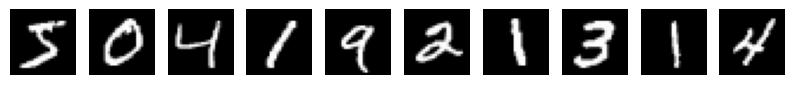

In [4]:
#Display Sample Images
plt.figure(figsize=(10, 2))

for i in range(10):
  plt.subplot(1, 10, i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.axis('off')
plt.show()

In [7]:
#Preprocess the Data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [8]:
#Build the Encoder
input_img = Input(shape=(784,))

encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(32, activation='relu', name='Latent_Space')(encoded)

In [9]:
#Build the Decoder
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

In [10]:
#Create the Autoencoder Model
autoencoder = Model(input_img, decoded)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [13]:
#Train the Model
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data = (x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0951 - val_loss: 3.1782e-05
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.0975e-05 - val_loss: 3.0881e-05
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 3.0142e-05 - val_loss: 3.0148e-05
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.9508e-05 - val_loss: 2.9615e-05
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 2.9052e-05 - val_loss: 2.9232e-05
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.8720e-05 - val_loss: 2.8945e-05
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 2.8463e-05 - val_loss: 2.8713e-05
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.8248e-05 - val_loss: 2.8512e-05
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.8058e-05 - val_loss: 2.8328e-05
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.7883e-05 - val_loss: 2.8155e-05
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step

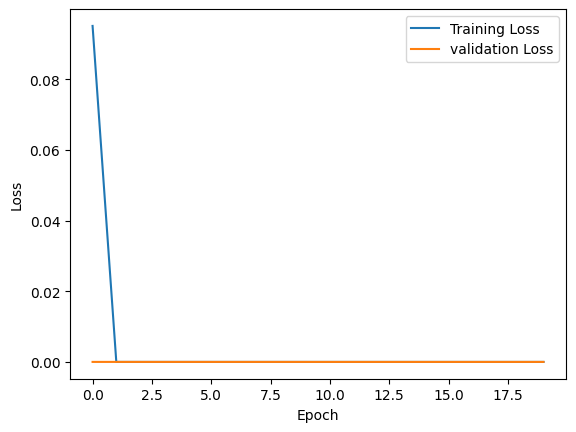

In [14]:
#Plot Training Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
#Predict Reconstructed Images
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


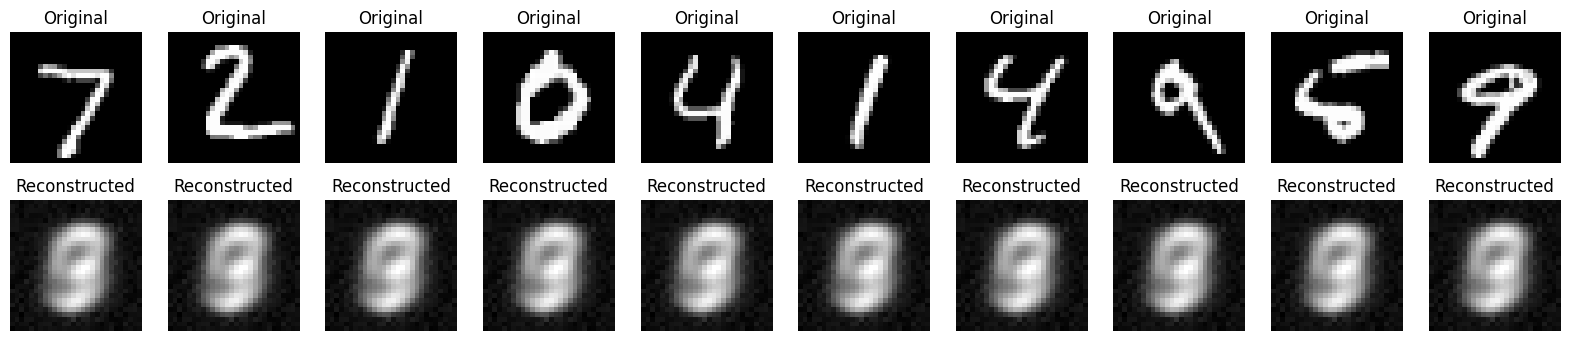

In [16]:
#Display Original vs Reconstructed Images
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

In [17]:
#Create Encoder Model
encoder = Model(input_img, latent)

In [18]:
#Get Latent Representation
latent_vectors = encoder.predict(x_test)
print(latent_vectors.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(10000, 32)


In [19]:
#Display First Latent Vector
print(latent_vectors[0])

[0.         0.89760536 0.         0.5505724  0.98154217 0.
 0.45494205 0.50270474 0.5719448  0.         0.34203336 0.
 0.49370456 0.6983408  0.86270064 0.         0.         0.6330311
 0.5313441  0.         1.0338006  1.0671939  0.6853716  0.95397496
 0.5638498  0.5284425  0.         0.5712617  0.         0.3789363
 0.457758   0.95523447]
